In [16]:
import sys
print(sys.version)
import re

3.14.2 (tags/v3.14.2:df79316, Dec  5 2025, 17:18:21) [MSC v.1944 64 bit (AMD64)]


In [17]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd

print("Libraries loaded successfully ")

Libraries loaded successfully 


In [18]:
model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded ")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 814.57it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded 


In [19]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

In [20]:
df = pd.read_json("News_Category_Dataset_v3.json", lines=True)

df["text"] = (
    df["headline"].fillna("") + " " +
    df["short_description"].fillna("")
).str.strip()

df = df[df["text"].str.len() > 0]

# Filter AI-related documents (FIXED regex)
ai_df = df[df["text"].str.contains(
    r"\b(ai|artificial intelligence|machine learning|data science)\b",
    case=False,
    na=False,
    regex=True
)]

print("AI-related docs found:", len(ai_df))

N_DOCS = min(200, len(ai_df))
docs_clean_raw = ai_df["text"].sample(n=N_DOCS, random_state=42).tolist()

C:\Users\jassk\AppData\Local\Temp\ipykernel_35720\2011669589.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ai_df = df[df["text"].str.contains(


AI-related docs found: 55


In [21]:
def clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"[^a-z0-9\s]", " ", s)   # remove punctuation
    s = re.sub(r"\s+", " ", s).strip()   # normalize spaces
    return s

In [22]:
blockers_raw = [
    "This document discusses important concepts in systems, models, data, learning, evaluation, performance, optimization and methods across many domains.",
    "A broad overview of AI, machine learning, data science, systems, development and evaluation with general principles and widely applicable concepts.",
    "General discussion of technology, research, science, modeling, metrics, methods and performance in modern computing and analytics.",
    "Artificial intelligence and machine learning involve models, training, evaluation, optimization, data pipelines, performance metrics and research methods used across applications.",
    "Data science includes modeling, analytics, machine learning, evaluation, experimentation, performance measurement and optimization in modern intelligent systems.",
    "Modern AI systems rely on data, algorithms, model training, evaluation, benchmarking, optimization and deployment in practical computing environments.",
    "Machine learning and artificial intelligence are widely used in data analysis, research, prediction, classification, optimization and decision support systems.",
    "Evaluation methods in AI and machine learning often involve metrics, models, datasets, experiments, performance analysis and optimization techniques.",
    "Research in artificial intelligence covers machine learning, data science, modeling, system performance, analytics, optimization and evaluation strategies.",
    "AI, data science and machine learning share concepts such as data processing, model development, experimentation, evaluation and performance improvement."
]

blockers = [clean_text(b) for b in blockers_raw]
print("Blockers:", len(blockers))

Blockers: 10


In [23]:

docs_clean = [clean_text(d) for d in docs_clean_raw]

# Create query-gold pairs using selected clean documents
gold_indices = [5, 25, 50, 75]

query_gold_pairs = []
for idx in gold_indices:
    if idx < len(docs_clean):
        doc_text = docs_clean[idx]
        short_query = " ".join(doc_text.split()[:8])   # first 8 words as query
        query_gold_pairs.append((short_query, idx))

print("Query-gold pairs:")
for q, idx in query_gold_pairs:
    print(f"Query: {q}... -> Gold doc index: {idx}")

doc_emb_clean = model.encode(docs_clean, normalize_embeddings=True)

docs_attacked = docs_clean + blockers
doc_emb_attacked = model.encode(docs_attacked, normalize_embeddings=True)

blocker_start_idx = len(docs_clean)

print("Clean embeddings shape:", doc_emb_clean.shape)
print("Attacked embeddings shape:", doc_emb_attacked.shape)
print("Blockers start index:", blocker_start_idx)

Query-gold pairs:
Query: ai day will replace christmas as the most... -> Gold doc index: 5
Query: facebook releases new tools to combat revenge porn... -> Gold doc index: 25
Query: artificial intelligence technology is breaking out of the... -> Gold doc index: 50
Clean embeddings shape: (55, 384)
Attacked embeddings shape: (65, 384)
Blockers start index: 55


In [24]:
def retrieve_topk_precomputed(query, docs, doc_emb, k=5):
    q = clean_text(query)
    q_emb = model.encode([q], normalize_embeddings=True)[0]
    scores = doc_emb @ q_emb
    top_idx = np.argsort(-scores)[:k]
    return [(int(i), docs[int(i)], float(scores[int(i)])) for i in top_idx]

query = "What is artificial intelligence and machine learning?"
k = 5

print("===== BEFORE (clean corpus) =====")
before = retrieve_topk_precomputed(query, docs_clean, doc_emb_clean, k)
for idx, text, score in before:
    print(f"[{idx}] score={score:.4f} | {text[:120]}...")

print("\n===== AFTER (clean + blockers) =====")
after = retrieve_topk_precomputed(query, docs_attacked, doc_emb_attacked, k)

blocker_hits = 0
for idx, text, score in after:
    is_blocker = idx >= blocker_start_idx
    blocker_hits += int(is_blocker)
    tag = "🚨BLOCKER" if is_blocker else "clean"
    print(f"[{idx}] {tag} score={score:.4f} | {text[:120]}...")

print(f"\nBlockers in top-{k}: {blocker_hits}/{k}")

===== BEFORE (clean corpus) =====
[7] score=0.5318 | artificial intelligence is here to change your life the revolution began before you even realized it...
[12] score=0.5080 | artificial intelligence is here to help us microsoft boss jean philippe courtois says we can augment human capabilities ...
[23] score=0.5034 | amazon is making it easier for companies to track you by adrienne lafrance like big data and social media before it the ...
[50] score=0.4739 | artificial intelligence technology is breaking out of the box the exponential improvement in the elements of computing i...
[37] score=0.4659 | how ai will redefine love artificial intelligence is beginning to disrupt entire industries from finance to medicine yet...

===== AFTER (clean + blockers) =====
[61] 🚨BLOCKER score=0.6790 | machine learning and artificial intelligence are widely used in data analysis research prediction classification optimiz...
[63] 🚨BLOCKER score=0.6753 | research in artificial intelligence covers mach

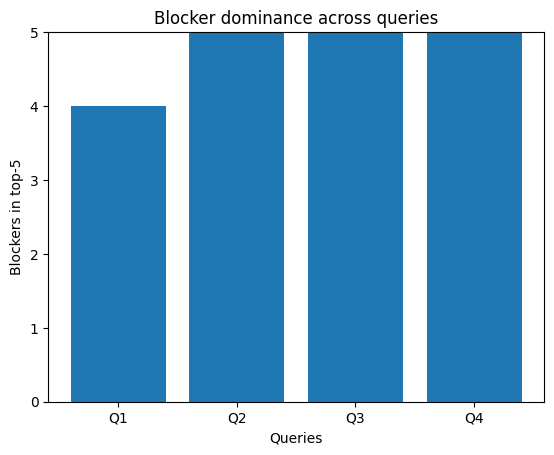

Q1: 4/5 blockers | What is data science?
Q2: 5/5 blockers | How does evaluation work in machine learning?
Q3: 5/5 blockers | How are models optimized in artificial intelligence?
Q4: 5/5 blockers | What are machine learning systems used for?


In [25]:
import matplotlib.pyplot as plt

queries = [
    "What is data science?",
    "How does evaluation work in machine learning?",
    "How are models optimized in artificial intelligence?",
    "What are machine learning systems used for?"
]
k = 5

blocker_counts = []
for q in queries:
    after = retrieve_topk_precomputed(q, docs_attacked, doc_emb_attacked, k)
    hits = sum(1 for idx, _, _ in after if idx >= blocker_start_idx)
    blocker_counts.append(hits)

plt.figure()
plt.bar(range(len(queries)), blocker_counts)
plt.xticks(range(len(queries)), [f"Q{i+1}" for i in range(len(queries))])
plt.ylim(0, k)
plt.xlabel("Queries")
plt.ylabel(f"Blockers in top-{k}")
plt.title("Blocker dominance across queries")
plt.show()

for i, (q, h) in enumerate(zip(queries, blocker_counts), start=1):
    print(f"Q{i}: {h}/{k} blockers | {q}")

In [26]:
from rank_bm25 import BM25Okapi
import numpy as np

tokenized_clean = [doc.split() for doc in docs_clean]
tokenized_attacked = [doc.split() for doc in docs_attacked]

bm25_clean = BM25Okapi(tokenized_clean)
bm25_attacked = BM25Okapi(tokenized_attacked)

In [27]:
print("BM25 ready")

def retrieve_bm25(query, docs, bm25, k=5):
    tokenized_query = clean_text(query).split()
    scores = bm25.get_scores(tokenized_query)
    top_idx = np.argsort(scores)[::-1][:k]
    return [(int(i), docs[int(i)], float(scores[int(i)])) for i in top_idx]

print("===== BM25 RESULTS (before vs after) =====")

for q in queries:
    print("\nQuery:", q)

    print("BEFORE (clean corpus)")
    before_results = retrieve_bm25(q, docs_clean, bm25_clean, k)
    for idx, text, score in before_results:
        print(f"  - [{idx}] clean score={score:.4f} | {text[:90]}...")

    print("AFTER (attacked corpus)")
    after_results = retrieve_bm25(q, docs_attacked, bm25_attacked, k)
    blocker_hits = sum(1 for idx, _, _ in after_results if idx >= blocker_start_idx)
    print(f"  Blockers in top-{k}: {blocker_hits}/{k}")

    for idx, text, score in after_results:
        tag = "🚨BLOCKER" if idx >= blocker_start_idx else "clean"
        print(f"  - [{idx}] {tag} score={score:.4f} | {text[:90]}...")

BM25 ready
===== BM25 RESULTS (before vs after) =====

Query: What is data science?
BEFORE (clean corpus)
  - [9] clean score=8.4296 | what your data scientist wishes you knew by daniel wesley big data it s the topic on every...
  - [45] clean score=4.3792 | how data science can help save the world when the indonesian government threatened to remo...
  - [6] clean score=4.0520 | from community college to the white house administration i m the u s chief data scientist ...
  - [15] clean score=3.3443 | is an ai arms race inevitable unlike nuclear weapons this new class can potentially target...
  - [51] clean score=3.1495 | massive tinder photo grab is latest scary warning to be careful what you post stealth swee...
AFTER (attacked corpus)
  Blockers in top-5: 3/5
  - [9] clean score=6.4941 | what your data scientist wishes you knew by daniel wesley big data it s the topic on every...
  - [64] 🚨BLOCKER score=4.0879 | ai data science and machine learning share concepts such as data proces

In [28]:
print("\n===== GOLD DOCUMENT RANK TEST: BM25 =====")

for query, gold_idx in query_gold_pairs:
    before_results = retrieve_bm25(query, docs_clean, bm25_clean, k=10)
    after_results = retrieve_bm25(query, docs_attacked, bm25_attacked, k=10)

    rank_before = get_rank_of_doc(before_results, gold_idx)
    rank_after = get_rank_of_doc(after_results, gold_idx)

    print("\nQuery:", query)
    print("Gold document index:", gold_idx)
    print("Rank BEFORE attack:", rank_before)
    print("Rank AFTER attack:", rank_after)


===== GOLD DOCUMENT RANK TEST: BM25 =====


NameError: name 'get_rank_of_doc' is not defined

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf_clean = TfidfVectorizer(stop_words='english')
tfidf_attacked = TfidfVectorizer(stop_words='english')

tfidf_matrix_clean = tfidf_clean.fit_transform(docs_clean)
tfidf_matrix_attacked = tfidf_attacked.fit_transform(docs_attacked)

print("TF-IDF ready")

def retrieve_tfidf(query, docs, tfidf_matrix, vectorizer, k=5):
    q_vec = vectorizer.transform([clean_text(query)])
    scores = cosine_similarity(q_vec, tfidf_matrix)[0]
    top_idx = scores.argsort()[::-1][:k]
    return [(int(i), docs[int(i)], float(scores[int(i)])) for i in top_idx]

In [ ]:
print("===== TF-IDF RESULTS (before vs after) =====")

for q in queries:
    print("\nQuery:", q)

    print("BEFORE (clean corpus)")
    before_results = retrieve_tfidf(q, docs_clean, tfidf_matrix_clean, tfidf_clean, k)
    for idx, text, score in before_results:
        print(f"  - [{idx}] clean score={score:.4f} | {text[:90]}...")

    print("AFTER (attacked corpus)")
    after_results = retrieve_tfidf(q, docs_attacked, tfidf_matrix_attacked, tfidf_attacked, k)
    blocker_hits = sum(1 for idx, _, _ in after_results if idx >= blocker_start_idx)
    print(f"  Blockers in top-{k}: {blocker_hits}/{k}")

    for idx, text, score in after_results:
        tag = "🚨BLOCKER" if idx >= blocker_start_idx else "clean"
        print(f"  - [{idx}] {tag} score={score:.4f} | {text[:90]}...")

TF-IDF ready


===== TF-IDF RESULTS (before vs after) =====

Query: What is data science?
BEFORE (clean corpus)
  - [9] clean score=0.5276 | what your data scientist wishes you knew by daniel wesley big data it s the topic on every...
  - [6] clean score=0.2828 | from community college to the white house administration i m the u s chief data scientist ...
  - [45] clean score=0.2495 | how data science can help save the world when the indonesian government threatened to remo...
  - [23] clean score=0.1538 | amazon is making it easier for companies to track you by adrienne lafrance like big data a...
  - [50] clean score=0.1226 | artificial intelligence technology is breaking out of the box the exponential improvement ...
AFTER (attacked corpus)
  Blockers in top-5: 4/5
  - [64] 🚨BLOCKER score=0.8012 | ai data science and machine learning share concepts such as data processing model developm...
  - [63] 🚨BLOCKER score=0.6683 | research in artificial intelligence covers machine learning data science mo

In [ ]:
print("\n===== GOLD DOCUMENT RANK TEST: TF-IDF =====")

for query, gold_idx in query_gold_pairs:
    before_results = retrieve_tfidf(query, docs_clean, tfidf_matrix_clean, tfidf_clean, k=10)
    after_results = retrieve_tfidf(query, docs_attacked, tfidf_matrix_attacked, tfidf_attacked, k=10)

    rank_before = get_rank_of_doc(before_results, gold_idx)
    rank_after = get_rank_of_doc(after_results, gold_idx)

    print("\nQuery:", query)
    print("Gold document index:", gold_idx)
    print("Rank BEFORE attack:", rank_before)
    print("Rank AFTER attack:", rank_after)

In [ ]:
def retrieve_hybrid(query, docs, doc_emb, bm25, k=5, alpha=0.5):
    q_emb = model.encode([clean_text(query)], normalize_embeddings=True)[0]
    dense_scores = doc_emb @ q_emb

    tokenized_query = clean_text(query).split()
    bm25_scores = bm25.get_scores(tokenized_query)

    dense_scores = np.array(dense_scores)
    bm25_scores = np.array(bm25_scores)

    dense_norm = (dense_scores - dense_scores.min()) / (dense_scores.max() - dense_scores.min() + 1e-8)
    bm25_norm = (bm25_scores - bm25_scores.min()) / (bm25_scores.max() - bm25_scores.min() + 1e-8)

    hybrid_scores = alpha * dense_norm + (1 - alpha) * bm25_norm

    top_idx = np.argsort(hybrid_scores)[::-1][:k]
    return [(int(i), docs[int(i)], float(hybrid_scores[int(i)])) for i in top_idx]

In [ ]:
print("===== HYBRID RESULTS (before vs after) =====")

for q in queries:
    print("\nQuery:", q)

    print("BEFORE (clean corpus)")
    before_results = retrieve_hybrid(q, docs_clean, doc_emb_clean, bm25_clean, k, alpha=0.5)
    for idx, text, score in before_results:
        print(f"  - [{idx}] clean score={score:.4f} | {text[:90]}...")

    print("AFTER (attacked corpus)")
    after_results = retrieve_hybrid(q, docs_attacked, doc_emb_attacked, bm25_attacked, k, alpha=0.5)
    blocker_hits = sum(1 for idx, _, _ in after_results if idx >= blocker_start_idx)
    print(f"  Blockers in top-{k}: {blocker_hits}/{k}")

    for idx, text, score in after_results:
        tag = "🚨BLOCKER" if idx >= blocker_start_idx else "clean"
        print(f"  - [{idx}] {tag} score={score:.4f} | {text[:90]}...")

===== HYBRID RESULTS (before vs after) =====

Query: What is data science?
BEFORE (clean corpus)
  - [9] clean score=1.0000 | what your data scientist wishes you knew by daniel wesley big data it s the topic on every...
  - [45] clean score=0.6121 | how data science can help save the world when the indonesian government threatened to remo...
  - [6] clean score=0.5830 | from community college to the white house administration i m the u s chief data scientist ...
  - [23] clean score=0.4151 | amazon is making it easier for companies to track you by adrienne lafrance like big data a...
  - [50] clean score=0.3923 | artificial intelligence technology is breaking out of the box the exponential improvement ...
AFTER (attacked corpus)
  Blockers in top-5: 4/5
  - [9] clean score=1.0000 | what your data scientist wishes you knew by daniel wesley big data it s the topic on every...
  - [59] 🚨BLOCKER score=0.7309 | data science includes modeling analytics machine learning evaluation experimenta

In [ ]:
print("\n===== GOLD DOCUMENT RANK TEST: DENSE =====")

for query, gold_idx in query_gold_pairs:
    before_results = retrieve_topk_precomputed(query, docs_clean, doc_emb_clean, k=10)
    after_results = retrieve_topk_precomputed(query, docs_attacked, doc_emb_attacked, k=10)

    rank_before = get_rank_of_doc(before_results, gold_idx)
    rank_after = get_rank_of_doc(after_results, gold_idx)

    print("\nQuery:", query)
    print("Gold document index:", gold_idx)
    print("Rank BEFORE attack:", rank_before)
    print("Rank AFTER attack:", rank_after)


===== GOLD DOCUMENT RANK TEST: DENSE =====


NameError: name 'get_rank_of_doc' is not defined

In [ ]:
print("\n===== RETRIEVAL METRICS (HIT@10 AND MRR@10) =====")

evaluation_summary = {}

evaluation_summary["Dense"] = evaluate_method(
    query_gold_pairs,
    retrieve_fn_clean=lambda q: retrieve_topk_precomputed(q, docs_clean, doc_emb_clean, k=10),
    retrieve_fn_attacked=lambda q: retrieve_topk_precomputed(q, docs_attacked, doc_emb_attacked, k=10),
    k=10
)

evaluation_summary["BM25"] = evaluate_method(
    query_gold_pairs,
    retrieve_fn_clean=lambda q: retrieve_bm25(q, docs_clean, bm25_clean, k=10),
    retrieve_fn_attacked=lambda q: retrieve_bm25(q, docs_attacked, bm25_attacked, k=10),
    k=10
)

evaluation_summary["TF-IDF"] = evaluate_method(
    query_gold_pairs,
    retrieve_fn_clean=lambda q: retrieve_tfidf(q, docs_clean, tfidf_matrix_clean, tfidf_clean, k=10),
    retrieve_fn_attacked=lambda q: retrieve_tfidf(q, docs_attacked, tfidf_matrix_attacked, tfidf_attacked, k=10),
    k=10
)

evaluation_summary["Hybrid"] = evaluate_method(
    query_gold_pairs,
    retrieve_fn_clean=lambda q: retrieve_hybrid(q, docs_clean, doc_emb_clean, bm25_clean, k=10, alpha=0.5),
    retrieve_fn_attacked=lambda q: retrieve_hybrid(q, docs_attacked, doc_emb_attacked, bm25_attacked, k=10, alpha=0.5),
    k=10
)

for method_name, metrics in evaluation_summary.items():
    print(f"\n{method_name}")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")


===== RETRIEVAL METRICS (HIT@10 AND MRR@10) =====


NameError: name 'evaluate_method' is not defined

In [ ]:
def get_rank_of_doc(results, target_idx):
    for rank, (idx, _, _) in enumerate(results, start=1):
        if idx == target_idx:
            return rank
    return None

def hit_at_k(rank, k):
    return 1 if rank is not None and rank <= k else 0

def reciprocal_rank(rank):
    return 1.0 / rank if rank is not None else 0.0

In [ ]:
def evaluate_method(query_gold_pairs, retrieve_fn_clean, retrieve_fn_attacked, k=10):
    clean_hits = []
    attacked_hits = []
    clean_rrs = []
    attacked_rrs = []

    for query, gold_idx in query_gold_pairs:
        clean_results = retrieve_fn_clean(query)
        attacked_results = retrieve_fn_attacked(query)

        clean_rank = get_rank_of_doc(clean_results, gold_idx)
        attacked_rank = get_rank_of_doc(attacked_results, gold_idx)

        clean_hits.append(hit_at_k(clean_rank, k))
        attacked_hits.append(hit_at_k(attacked_rank, k))

        clean_rrs.append(reciprocal_rank(clean_rank))
        attacked_rrs.append(reciprocal_rank(attacked_rank))

    return {
        "Hit@K Clean": np.mean(clean_hits),
        "Hit@K Attacked": np.mean(attacked_hits),
        "MRR Clean": np.mean(clean_rrs),
        "MRR Attacked": np.mean(attacked_rrs),
    }

In [ ]:
metric_names = ["Hit@K Clean", "Hit@K Attacked", "MRR Clean", "MRR Attacked"]
method_names = list(evaluation_summary.keys())

for metric in metric_names:
    values = [evaluation_summary[m][metric] for m in method_names]

    plt.figure()
    plt.bar(method_names, values)
    plt.ylim(0, 1)
    plt.xlabel("Retrieval Method")
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison Across Methods")
    plt.show()

In [ ]:
methods = {
    "Dense": lambda q: retrieve_topk_precomputed(q, docs_attacked, doc_emb_attacked, k),
    "BM25": lambda q: retrieve_bm25(q, docs_attacked, bm25_attacked, k),
    "TF-IDF": lambda q: retrieve_tfidf(q, docs_attacked, tfidf_matrix_attacked, tfidf_attacked, k),
    "Hybrid": lambda q: retrieve_hybrid(q, docs_attacked, doc_emb_attacked, bm25_attacked, k, alpha=0.5),
}

print("===== METHOD COMPARISON =====")

for method_name, method_fn in methods.items():
    print(f"\n{method_name}")
    for q in queries:
        results = method_fn(q)
        blocker_hits = sum(1 for idx, _, _ in results if idx >= blocker_start_idx)
        print(f"  {q} -> {blocker_hits}/{k} blockers")

===== METHOD COMPARISON =====

Dense
  What is data science? -> 4/5 blockers
  How does evaluation work in machine learning? -> 5/5 blockers
  What is optimization in AI? -> 5/5 blockers
  What is retrieval augmented generation? -> 3/5 blockers

BM25
  What is data science? -> 3/5 blockers
  How does evaluation work in machine learning? -> 5/5 blockers
  What is optimization in AI? -> 3/5 blockers
  What is retrieval augmented generation? -> 0/5 blockers

TF-IDF


AttributeError: 'int' object has no attribute 'transform'

Computed blocker counts automatically:
Dense -> [4, 5, 5, 3]
BM25 -> [3, 5, 3, 0]
TF-IDF -> [4, 3, 2, 5]
Hybrid -> [4, 5, 5, 0]


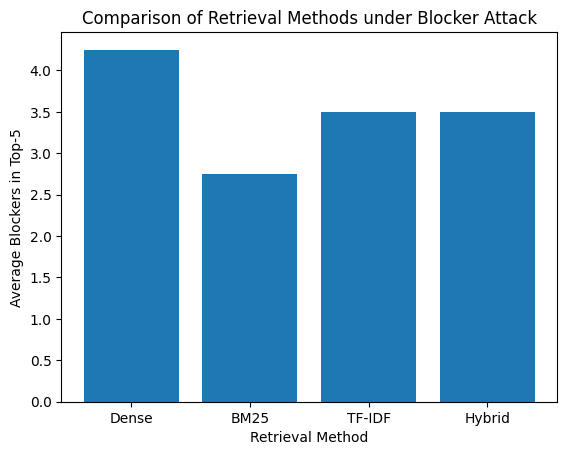

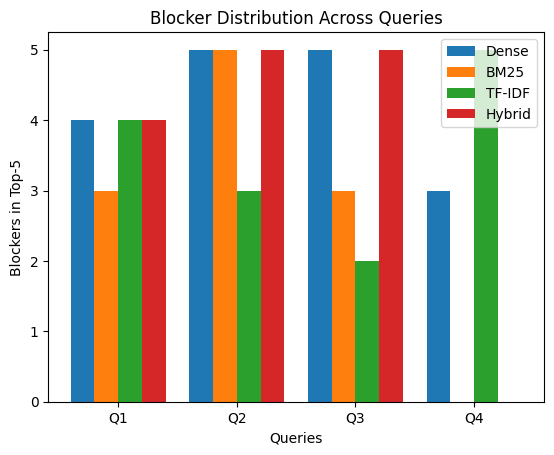

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

method_results = {}

for method_name, method_fn in methods.items():
    blocker_list = []
    for q in queries:
        results = method_fn(q)
        blocker_hits = sum(1 for idx, _, _ in results if idx >= blocker_start_idx)
        blocker_list.append(blocker_hits)
    method_results[method_name] = blocker_list

print("Computed blocker counts automatically:")
for method_name, blocker_list in method_results.items():
    print(method_name, "->", blocker_list)

# Average blockers for each method
method_names = list(method_results.keys())
avg_scores = [np.mean(method_results[m]) for m in method_names]

plt.figure()
plt.bar(method_names, avg_scores)
plt.xlabel("Retrieval Method")
plt.ylabel(f"Average Blockers in Top-{k}")
plt.title("Comparison of Retrieval Methods under Blocker Attack")
plt.show()

# Blockers per query for each method
queries_labels = [f"Q{i+1}" for i in range(len(queries))]
x = np.arange(len(queries_labels))
width = 0.2

plt.figure()
for i, method_name in enumerate(method_names):
    plt.bar(x + (i - 1.5) * width, method_results[method_name], width, label=method_name)

plt.xticks(x, queries_labels)
plt.xlabel("Queries")
plt.ylabel(f"Blockers in Top-{k}")
plt.title("Blocker Distribution Across Queries")
plt.legend()
plt.show()